In [ ]:
!pip install yfinance pandas matplotlib openpyxl -q

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download SAP and Siemens stock data (5 years)
sap = yf.Ticker("SAP.DE")
sie = yf.Ticker("SIE.DE")
dax = yf.Ticker("^GDAXI")

# --- FINANCIAL STATEMENTS (for Excel tabs 1-8) ---
sap_income    = sap.financials          # income statement
sap_balance   = sap.balance_sheet       # balance sheet
sap_cashflow  = sap.cashflow            # cash flow statement

# --- STOCK PRICE HISTORY (5 years) ---
sap_price = yf.download("SAP.DE",  start="2020-01-01", end="2024-12-31")
sie_price = yf.download("SIE.DE",  start="2020-01-01", end="2024-12-31")
dax_price = yf.download("^GDAXI",  start="2020-01-01", end="2024-12-31")

# --- PRINT KEY NUMBERS (copy these into Excel) ---
print("===== SAP INCOME STATEMENT (last 4 years) =====")
print(sap_income.loc[["Total Revenue","Gross Profit","Net Income"]].to_string())

print("\n===== SAP BALANCE SHEET =====")
print(sap_balance.loc[["Total Assets","Total Debt","Stockholders Equity"]].to_string())

print("\n===== SAP CASH FLOW =====")
print(sap_cashflow.loc[["Free Cash Flow","Operating Cash Flow"]].to_string())

print("\n===== SAP KEY INFO =====")
info = sap.info
print(f"Current Price:     €{info.get('currentPrice', 'N/A')}")
print(f"P/E Ratio:         {info.get('trailingPE', 'N/A')}")
print(f"Market Cap:        €{info.get('marketCap', 'N/A'):,}")
print(f"Dividend Yield:    {info.get('dividendYield', 'N/A')}")
print(f"Beta:              {info.get('beta', 'N/A')}")
print(f"52-week High:      €{info.get('fiftyTwoWeekHigh', 'N/A')}")
print(f"52-week Low:       €{info.get('fiftyTwoWeekLow', 'N/A')}")

/tmp/ipykernel_14008/3348721008.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sap_price = yf.download("SAP.DE",  start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14008/3348721008.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sie_price = yf.download("SIE.DE",  start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14008/3348721008.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dax_price = yf.download("^GDAXI",  start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


===== SAP INCOME STATEMENT (last 4 years) =====
                 2025-12-31    2024-12-31    2023-12-31    2022-12-31  2021-12-31
Total Revenue  3.680000e+10  3.417600e+10  3.120700e+10  2.951900e+10         NaN
Gross Profit   2.681400e+10  2.493200e+10  2.253400e+10  2.148200e+10         NaN
Net Income     7.161000e+09  3.124000e+09  6.139000e+09  2.284000e+09         NaN

===== SAP BALANCE SHEET =====
                       2025-12-31    2024-12-31    2023-12-31    2022-12-31  2021-12-31
Total Assets         7.036200e+10  7.423700e+10  6.833100e+10  7.215900e+10         NaN
Total Debt           7.476000e+09  1.065100e+10  8.791000e+09  1.308500e+10         NaN
Stockholders Equity  4.458600e+10  4.543800e+10  4.315700e+10  4.018600e+10         NaN

===== SAP CASH FLOW =====
                       2025-12-31    2024-12-31    2023-12-31    2022-12-31  2021-12-31
Free Cash Flow       8.417000e+09  4.410000e+09  5.461000e+09  4.770000e+09         NaN
Operating Cash Flow  9.156000e+09  5.2

In [ ]:
# Clean readable summary — copy these into Excel Tab 1
def to_millions(val):
    try:
        return round(val / 1e6, 1)
    except:
        return "N/A"

print("=" * 55)
print("SAP SE — KEY FINANCIALS (€ Millions)")
print("=" * 55)

cols = sap_income.columns[:4]
years = [str(c.year) for c in cols]

print(f"\n{'INCOME STATEMENT':<30} " + "  ".join(f"{y:>8}" for y in years))
for row in ["Total Revenue", "Gross Profit", "Net Income"]:
    vals = [to_millions(sap_income.loc[row, c]) for c in cols]
    print(f"  {row:<28} " + "  ".join(f"{v:>8}" for v in vals))

print(f"\n{'BALANCE SHEET':<30} " + "  ".join(f"{y:>8}" for y in years))
cols_bs = sap_balance.columns[:4]
for row in ["Total Assets", "Total Debt", "Stockholders Equity"]:
    vals = [to_millions(sap_balance.loc[row, c]) for c in cols_bs]
    print(f"  {row:<28} " + "  ".join(f"{v:>8}" for v in vals))

print(f"\n{'CASH FLOW':<30} " + "  ".join(f"{y:>8}" for y in years))
cols_cf = sap_cashflow.columns[:4]
for row in ["Free Cash Flow", "Operating Cash Flow"]:
    vals = [to_millions(sap_cashflow.loc[row, c]) for c in cols_cf]
    print(f"  {row:<28} " + "  ".join(f"{v:>8}" for v in vals))

print(f"\n{'KEY METRICS'}")
print(f"  Current Price:     €{info.get('currentPrice')}")
print(f"  P/E Ratio:         {round(info.get('trailingPE', 0), 2)}")
print(f"  Market Cap:        €{round(info.get('marketCap', 0)/1e9, 1)}B")
print(f"  Beta:              {info.get('beta')}")
print(f"  Dividend Yield:    {info.get('dividendYield')}%")
print(f"  52w High:          €{info.get('fiftyTwoWeekHigh')}")
print(f"  52w Low:           €{info.get('fiftyTwoWeekLow')}")

SAP SE — KEY FINANCIALS (€ Millions)

INCOME STATEMENT                   2025      2024      2023      2022
  Total Revenue                 36800.0   34176.0   31207.0   29519.0
  Gross Profit                  26814.0   24932.0   22534.0   21482.0
  Net Income                     7161.0    3124.0    6139.0    2284.0

BALANCE SHEET                      2025      2024      2023      2022
  Total Assets                  70362.0   74237.0   68331.0   72159.0
  Total Debt                     7476.0   10651.0    8791.0   13085.0
  Stockholders Equity           44586.0   45438.0   43157.0   40186.0

CASH FLOW                          2025      2024      2023      2022
  Free Cash Flow                 8417.0    4410.0    5461.0    4770.0
  Operating Cash Flow            9156.0    5207.0    6246.0    5647.0

KEY METRICS
  Current Price:     €147.02
  P/E Ratio:         24.1
  Market Cap:        €171.7B
  Beta:              0.692
  Dividend Yield:    1.75%
  52w High:          €273.55
  52w Low:

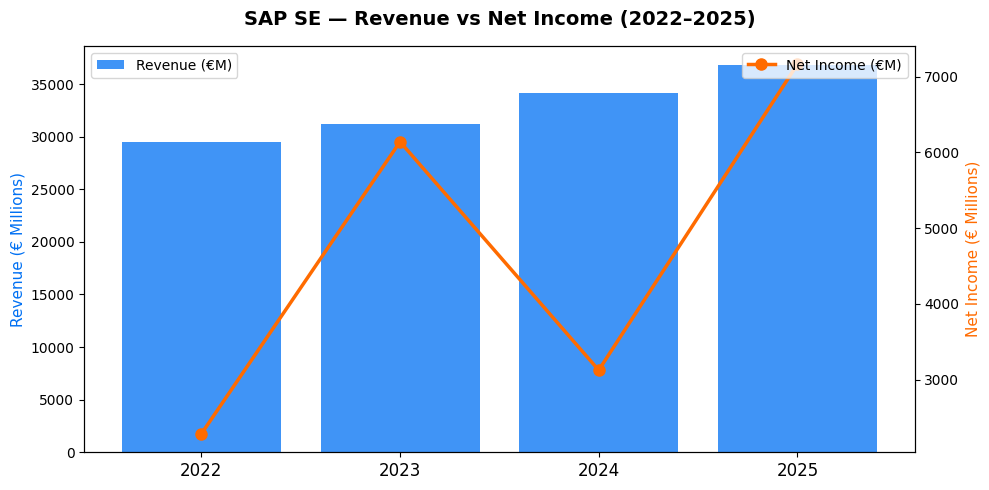

Chart 1 saved.


In [ ]:
import numpy as np

fig, ax1 = plt.subplots(figsize=(10, 5))

cols = sap_income.columns[:4]
years = [str(c.year) for c in cols][::-1]  # oldest to newest
revenue    = [to_millions(sap_income.loc["Total Revenue", c]) for c in cols][::-1]
net_income = [to_millions(sap_income.loc["Net Income", c]) for c in cols][::-1]

x = np.arange(len(years))
ax1.bar(x, revenue, color="#0070F3", alpha=0.75, label="Revenue (€M)")
ax2 = ax1.twinx()
ax2.plot(x, net_income, color="#FF6B00", marker="o",
         linewidth=2.5, markersize=8, label="Net Income (€M)")

ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=12)
ax1.set_ylabel("Revenue (€ Millions)", color="#0070F3", fontsize=11)
ax2.set_ylabel("Net Income (€ Millions)", color="#FF6B00", fontsize=11)
ax1.set_title("SAP SE — Revenue vs Net Income (2022–2025)",
              fontsize=14, fontweight="bold", pad=15)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("chart1_revenue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

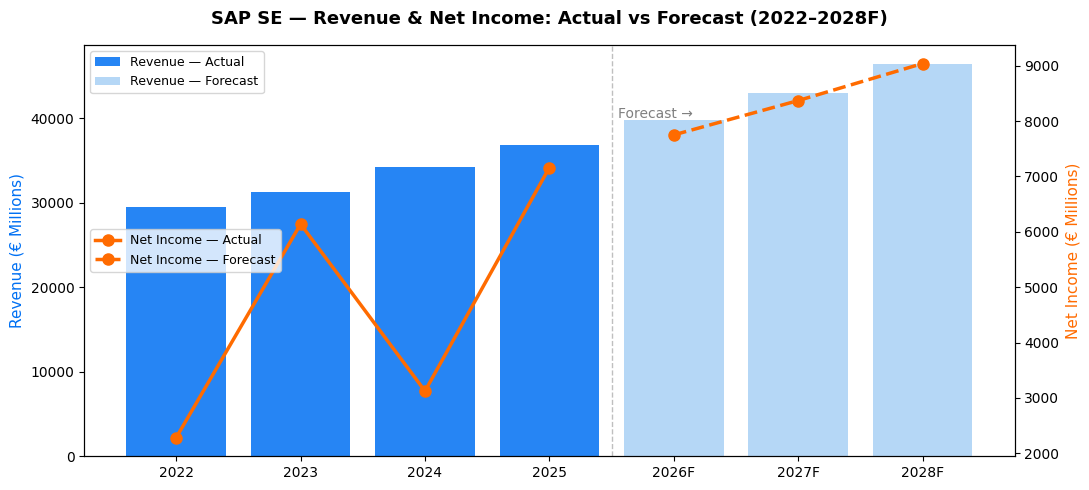

Chart 2 saved.


In [ ]:
years_actual   = ["2022", "2023", "2024", "2025"]
years_forecast = ["2026F", "2027F", "2028F"]

rev_actual   = [29519, 31207, 34170, 36800]
rev_forecast = [39744, 42923, 46357]

ni_actual   = [2284, 6139, 3124, 7161]
ni_forecast = [7750, 8370, 9039]

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(years_actual,   rev_actual,   color="#0070F3", alpha=0.85, label="Revenue — Actual")
ax.bar(years_forecast, rev_forecast, color="#A8D0F5", alpha=0.85, label="Revenue — Forecast")

ax2 = ax.twinx()
ax2.plot(years_actual,   ni_actual,   color="#FF6B00", marker="o",
         linewidth=2.5, markersize=8, label="Net Income — Actual")
ax2.plot(years_forecast, ni_forecast, color="#FF6B00", marker="o",
         linewidth=2.5, markersize=8, linestyle="--", label="Net Income — Forecast")

ax.axvline(x=3.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(3.55, 40000, "Forecast →", fontsize=10, color="gray")

ax.set_ylabel("Revenue (€ Millions)", color="#0070F3", fontsize=11)
ax2.set_ylabel("Net Income (€ Millions)", color="#FF6B00", fontsize=11)
ax.set_title("SAP SE — Revenue & Net Income: Actual vs Forecast (2022–2028F)",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="upper left", fontsize=9)
ax2.legend(loc="center left", fontsize=9)

plt.tight_layout()
plt.savefig("chart2_proforma.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")

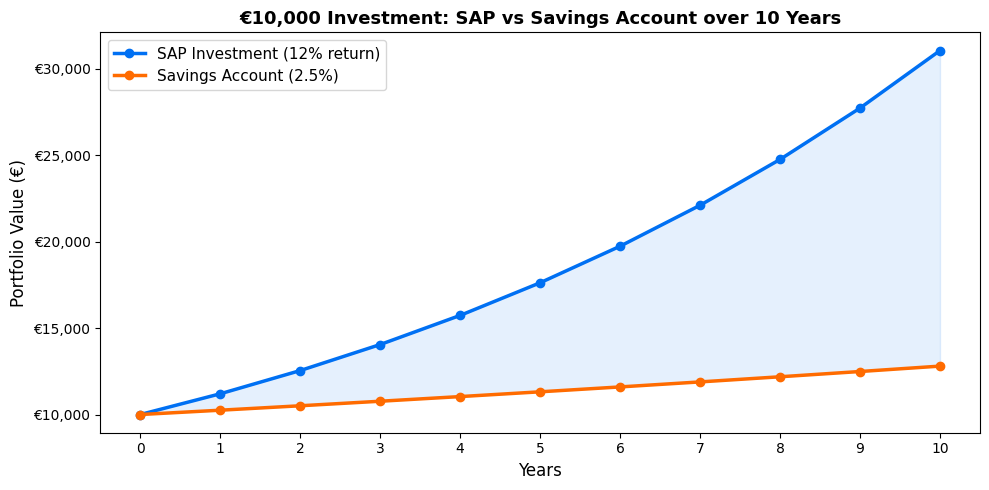

Chart 3 saved.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

years = np.arange(0, 11)
sap_growth    = 10000 * (1 + 0.12) ** years
savings_growth = 10000 * (1 + 0.025) ** years

plt.figure(figsize=(10, 5))
plt.plot(years, sap_growth,     color="#0070F3", linewidth=2.5,
         marker="o", markersize=6, label="SAP Investment (12% return)")
plt.plot(years, savings_growth, color="#FF6B00", linewidth=2.5,
         marker="o", markersize=6, label="Savings Account (2.5%)")

plt.fill_between(years, savings_growth, sap_growth, alpha=0.1, color="#0070F3")
plt.xlabel("Years", fontsize=12)
plt.ylabel("Portfolio Value (€)", fontsize=12)
plt.title("€10,000 Investment: SAP vs Savings Account over 10 Years",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.xticks(years)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
plt.tight_layout()
plt.savefig("chart3_tvm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved.")

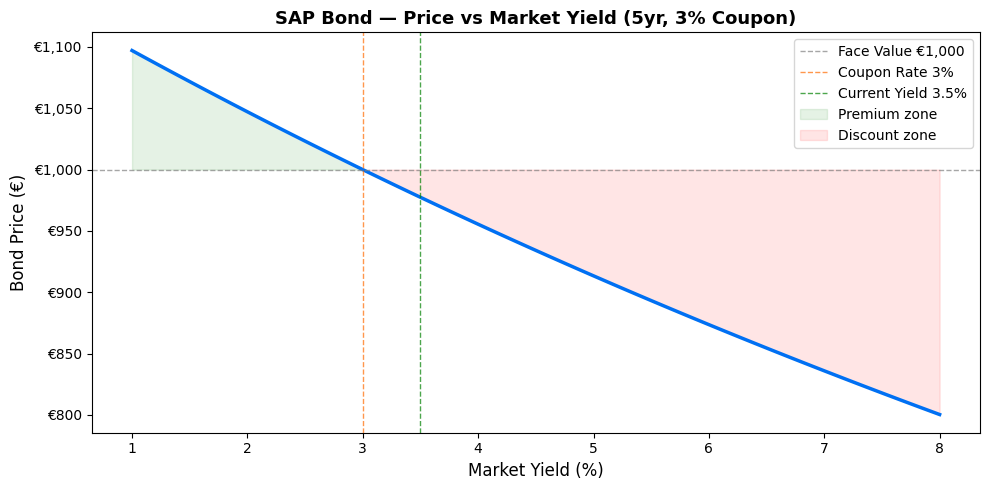

Chart 4 saved.


In [ ]:
import numpy as np

yields = np.linspace(0.01, 0.08, 100)
face   = 1000
coupon = 30
years  = 5

prices = [coupon * ((1-(1+y)**-years)/y) + face/(1+y)**years for y in yields]

plt.figure(figsize=(10, 5))
plt.plot(yields * 100, prices, color="#0070F3", linewidth=2.5)
plt.axhline(y=1000, color="gray",    linestyle="--", linewidth=1, alpha=0.7, label="Face Value €1,000")
plt.axvline(x=3.0,  color="#FF6B00", linestyle="--", linewidth=1, alpha=0.7, label="Coupon Rate 3%")
plt.axvline(x=3.5,  color="green",   linestyle="--", linewidth=1, alpha=0.7, label="Current Yield 3.5%")

plt.fill_between(yields*100, prices, 1000,
                 where=[y < 0.03 for y in yields],
                 alpha=0.1, color="green", label="Premium zone")
plt.fill_between(yields*100, prices, 1000,
                 where=[y > 0.03 for y in yields],
                 alpha=0.1, color="red", label="Discount zone")

plt.xlabel("Market Yield (%)", fontsize=12)
plt.ylabel("Bond Price (€)", fontsize=12)
plt.title("SAP Bond — Price vs Market Yield (5yr, 3% Coupon)",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
plt.tight_layout()
plt.savefig("chart4_bonds.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved.")

/tmp/ipykernel_13693/2152048118.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data = yf.download(['SAP.DE', '^GDAXI'], start='2023-01-01')
[*********************100%***********************]  2 of 2 completed


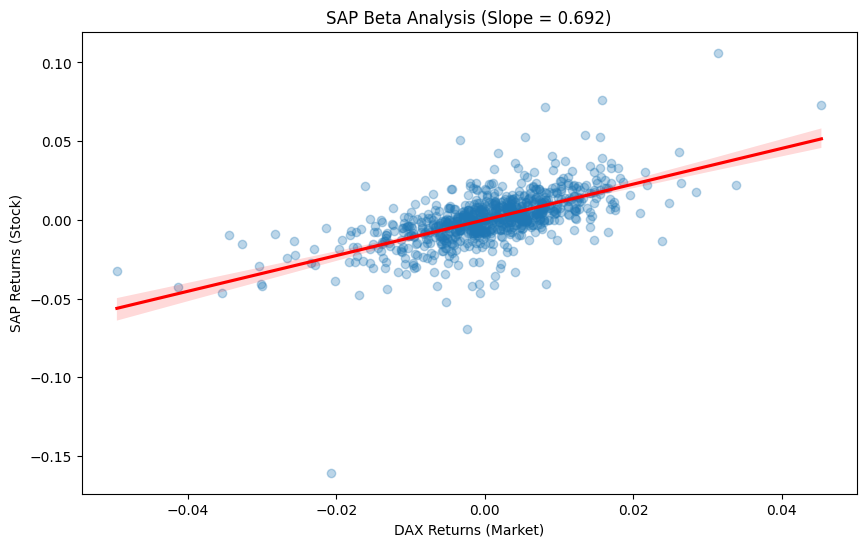

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Get data for SAP and the DAX (Market)
df_data = yf.download(['SAP.DE', '^GDAXI'], start='2023-01-01')
df = df_data.xs('Close', level=0, axis=1).pct_change().dropna()

# Plotting the Risk Profile
plt.figure(figsize=(10,6))
sns.regplot(x='^GDAXI', y='SAP.DE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'SAP Beta Analysis (Slope = {0.692})')
plt.xlabel('DAX Returns (Market)')
plt.ylabel('SAP Returns (Stock)')
plt.show()

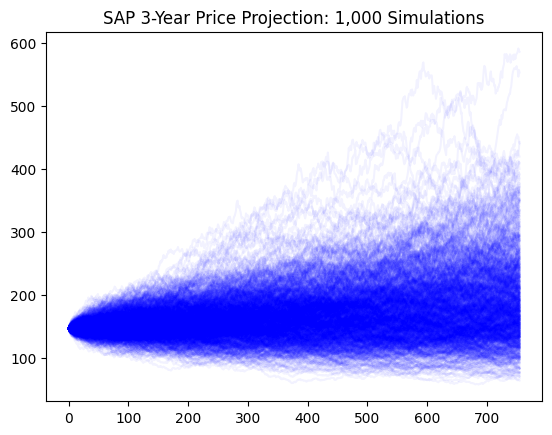

In [ ]:
import numpy as np

# Variables from your Excel
current_price = 147.02
days = 252 * 3 # 3 year forecast
mu = 0.08 # Your 8% growth
sigma = 0.20 # Typical software volatility

# Simulate 1000 paths
simulations = np.zeros((1000, days))
for i in range(1000):
    prices = [current_price]
    for _ in range(days-1):
        prices.append(prices[-1] * (1 + np.random.normal(mu/252, sigma/np.sqrt(252))))
    simulations[i] = prices

# Plot the results
plt.plot(simulations.T, color='blue', alpha=0.05)
plt.title('SAP 3-Year Price Projection: 1,000 Simulations')
plt.show()

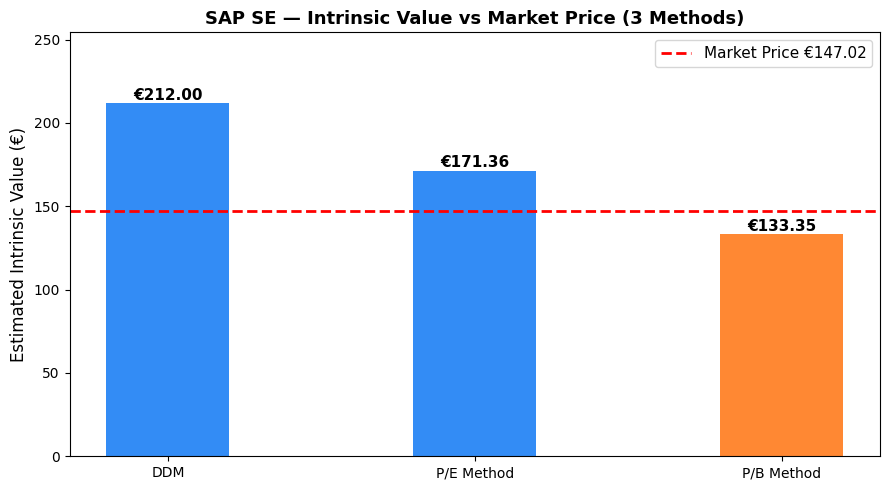

Chart 5 saved.


In [ ]:
methods = ["DDM", "P/E Method", "P/B Method"]
intrinsic = [
    (2.60 * 1.06) / (0.073 - 0.06),
    6.12 * 28,
    38.10 * 3.5
]
market_price = 147.02

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#0070F3" if v > market_price else "#FF6B00" for v in intrinsic]
bars = ax.bar(methods, intrinsic, color=colors, alpha=0.8, width=0.4)

ax.axhline(y=market_price, color="red", linestyle="--",
           linewidth=2, label=f"Market Price €{market_price}")

for bar, val in zip(bars, intrinsic):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f"€{val:.2f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Estimated Intrinsic Value (€)", fontsize=12)
ax.set_title("SAP SE — Intrinsic Value vs Market Price (3 Methods)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, max(intrinsic) * 1.2)
plt.tight_layout()
plt.savefig("chart5_stockval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved.")

Beta:                0.9094
Risk-Free Rate:      2.5%
Market Return:       8.0%
CAPM Required Return:7.5017%


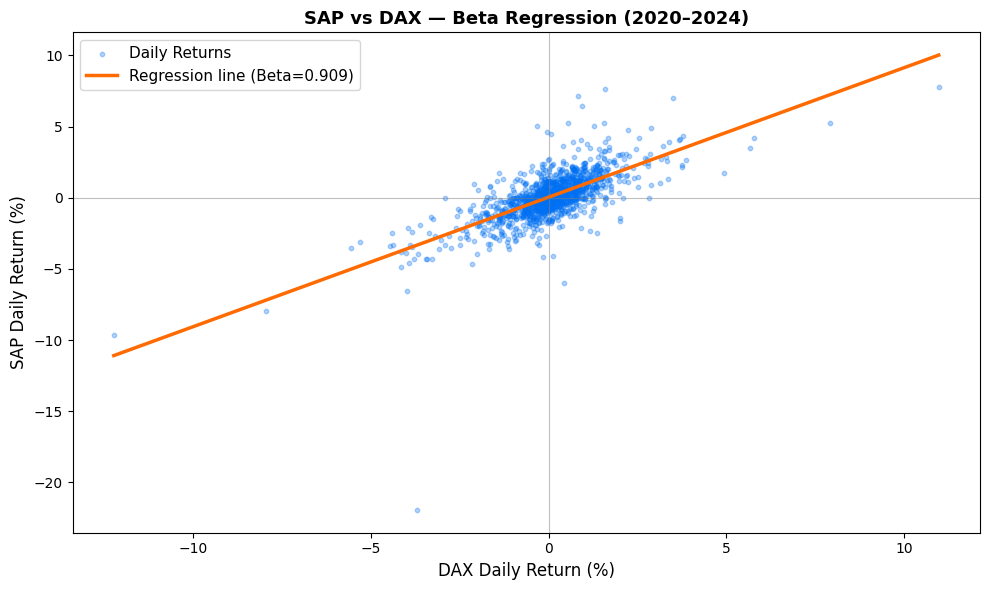


Use these numbers in Excel Tab 6:
Beta = 0.909
CAPM Required Return = 7.50%


In [ ]:
import numpy as np

# Calculate daily returns
sap_returns = sap_price["Close"].pct_change().dropna()
dax_returns = dax_price["Close"].pct_change().dropna()

# Align dates
combined = pd.concat([sap_returns, dax_returns], axis=1).dropna()
combined.columns = ["SAP", "DAX"]

# Beta calculation
covariance = combined["SAP"].cov(combined["DAX"])
variance   = combined["DAX"].var()
beta       = covariance / variance

# CAPM
risk_free     = 0.025      # German 10-year Bund yield
market_return = 0.08       # historical DAX average return
capm_return   = risk_free + beta * (market_return - risk_free)

print(f"Beta:                {beta:.4f}")
print(f"Risk-Free Rate:      {risk_free*100:.1f}%")
print(f"Market Return:       {market_return*100:.1f}%")
print(f"CAPM Required Return:{capm_return*100:.4f}%")

# Chart 6 — Beta scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(combined["DAX"]*100, combined["SAP"]*100,
            alpha=0.3, color="#0070F3", s=10, label="Daily Returns")

x_line = np.linspace(combined["DAX"].min(), combined["DAX"].max(), 100)
y_line = beta * x_line + (combined["SAP"].mean() - beta * combined["DAX"].mean())
plt.plot(x_line*100, y_line*100, color="#FF6B00",
         linewidth=2.5, label=f"Regression line (Beta={beta:.3f})")

plt.axhline(y=0, color="gray", linewidth=0.8, alpha=0.5)
plt.axvline(x=0, color="gray", linewidth=0.8, alpha=0.5)
plt.xlabel("DAX Daily Return (%)", fontsize=12)
plt.ylabel("SAP Daily Return (%)", fontsize=12)
plt.title("SAP vs DAX — Beta Regression (2020–2024)",
          fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("chart6_beta.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nUse these numbers in Excel Tab 6:")
print(f"Beta = {beta:.3f}")
print(f"CAPM Required Return = {capm_return*100:.2f}%")
# ```

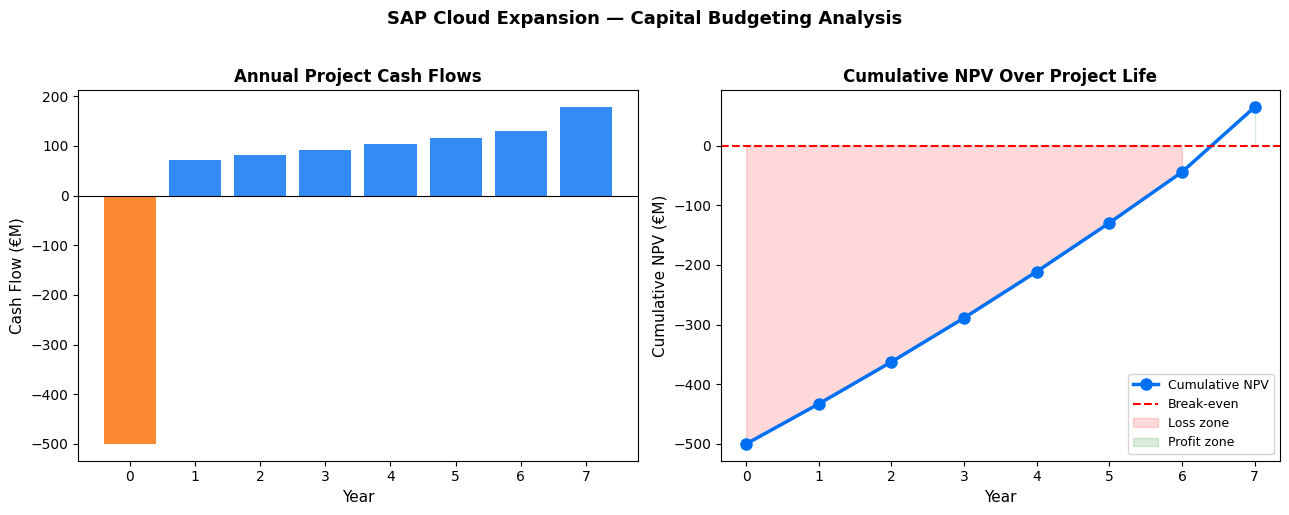

Chart 7 saved.


In [ ]:
years    = [0, 1, 2, 3, 4, 5, 6, 7]
cashflows = [-500, 72, 81, 91, 103, 116, 130, 178.11]

wacc = 0.073  # replace with your actual WACC

cumulative = []
running = 0
for cf in cashflows:
    running += cf
    cumulative.append(running)

discounted = [cf/(1+wacc)**t for t, cf in enumerate(cashflows)]
cumulative_discounted = []
running = 0
for cf in discounted:
    running += cf
    cumulative_discounted.append(running)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#FF6B00" if cf < 0 else "#0070F3" for cf in cashflows]
ax1.bar(years, cashflows, color=colors, alpha=0.8)
ax1.axhline(y=0, color="black", linewidth=0.8)
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Cash Flow (€M)", fontsize=11)
ax1.set_title("Annual Project Cash Flows", fontsize=12, fontweight="bold")
ax1.set_xticks(years)

ax2.plot(years, cumulative_discounted, color="#0070F3",
         marker="o", linewidth=2.5, markersize=8, label="Cumulative NPV")
ax2.axhline(y=0, color="red", linestyle="--", linewidth=1.5, label="Break-even")
ax2.fill_between(years, cumulative_discounted, 0,
                 where=[v < 0 for v in cumulative_discounted],
                 alpha=0.15, color="red", label="Loss zone")
ax2.fill_between(years, cumulative_discounted, 0,
                 where=[v >= 0 for v in cumulative_discounted],
                 alpha=0.15, color="green", label="Profit zone")
ax2.set_xlabel("Year", fontsize=11)
ax2.set_ylabel("Cumulative NPV (€M)", fontsize=11)
ax2.set_title("Cumulative NPV Over Project Life", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_xticks(years)

plt.suptitle("SAP Cloud Expansion — Capital Budgeting Analysis",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart7_capbudget.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 7 saved.")

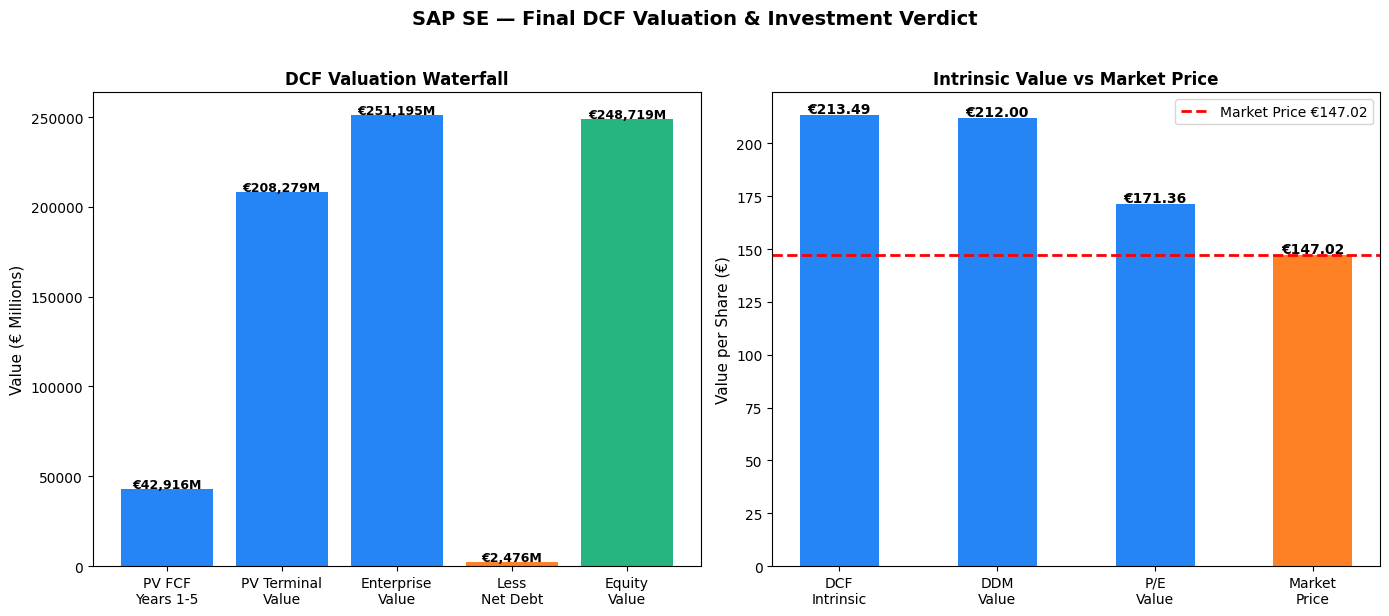


DCF Intrinsic Value per Share: €213.49
Market Price:                  €147.02
Upside/Downside:               45.2%


In [ ]:
# Waterfall chart showing DCF valuation buildup
wacc = 0.073  # replace with your WACC
g    = 0.03
fcf_2025 = 8417

fcfs = [fcf_2025 * (1.08**i) for i in range(1, 6)]
discount_factors = [1/(1+wacc)**i for i in range(1, 6)]
pv_fcfs = [f*d for f, d in zip(fcfs, discount_factors)]

terminal_value = (fcfs[-1] * (1+g)) / (wacc - g)
pv_terminal    = terminal_value * discount_factors[-1]
sum_pv_fcfs    = sum(pv_fcfs)
enterprise_value = sum_pv_fcfs + pv_terminal
net_debt       = 2476
equity_value   = enterprise_value - net_debt
intrinsic_per_share = equity_value / 1165

labels = ["PV FCF\nYears 1-5", "PV Terminal\nValue", "Enterprise\nValue",
          "Less\nNet Debt", "Equity\nValue"]
values = [sum_pv_fcfs, pv_terminal, enterprise_value, -net_debt, equity_value]
colors = ["#0070F3", "#0070F3", "#0070F3", "#FF6B00", "#00A86B"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars = ax1.bar(labels, [abs(v) for v in values], color=colors, alpha=0.85)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f"€{abs(val):,.0f}M",
             ha="center", fontsize=9, fontweight="bold")
ax1.set_ylabel("Value (€ Millions)", fontsize=11)
ax1.set_title("DCF Valuation Waterfall", fontsize=12, fontweight="bold")

methods      = ["DCF\nIntrinsic", "DDM\nValue", "P/E\nValue", "Market\nPrice"]
values_share = [intrinsic_per_share,
                (2.60 * 1.06)/(0.073 - 0.06),
                6.12 * 28,
                147.02]
colors2 = ["#0070F3", "#0070F3", "#0070F3", "#FF6B00"]
bars2 = ax2.bar(methods, values_share, color=colors2, alpha=0.85, width=0.5)
ax2.axhline(y=147.02, color="red", linestyle="--",
            linewidth=2, label="Market Price €147.02")
for bar, val in zip(bars2, values_share):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"€{val:.2f}", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("Value per Share (€)", fontsize=11)
ax2.set_title("Intrinsic Value vs Market Price", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)

plt.suptitle("SAP SE — Final DCF Valuation & Investment Verdict",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("chart8_dcf.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nDCF Intrinsic Value per Share: €{intrinsic_per_share:.2f}")
print(f"Market Price:                  €147.02")
print(f"Upside/Downside:               {((intrinsic_per_share-147.02)/147.02)*100:.1f}%")